In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as funcy
import torch.optim as opti
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [28]:
dev=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [76]:
data=datasets.MNIST(root='./mnist',train=True,download=True,transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))]))

In [77]:
load=DataLoader(data,batch_size=64,shuffle=True,num_workers=2)

In [78]:
class RanSinuEmb(nn.Module):
    def __init__(self,embd,scale=30):
        super().__init__()
        self.W=nn.Parameter(torch.randn(embd//2)*scale,requires_grad=False)
    def forward(self,x):
        xp=x[:,None]*self.W[None,:]*2*np.pi
        return torch.cat([torch.sin(xp),torch.cos(xp)],dim=-1)

In [79]:
class Didd(nn.Module):
    def __init__(self,inn,out):
        super().__init__()
        self.did=nn.Linear(inn,out)
    def forward(self,x):
        return self.did(x)[...,None,None]

In [80]:
class Score(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb=nn.Sequential(RanSinuEmb(embd=128),
                               nn.Linear(128,128),
                               nn.SiLU(),
                               nn.Linear(128,64),)
        self.c1=nn.Conv2d(1,32,3,padding=1)
        self.d1=Didd(64,32)
        self.c2=nn.Conv2d(32,64,3,stride=2,padding=1)
        self.d2=Didd(64,64)
        self.c3=nn.Conv2d(64,128,3,stride=2,padding=1)
        self.d3=Didd(64,128)
        self.tc3=nn.ConvTranspose2d(128,64,3,stride=2,padding=1,output_padding=1)
        self.td3=Didd(64,64)
        self.tc2=nn.ConvTranspose2d(128,32,3,stride=2,padding=1,output_padding=1)
        self.td2=Didd(64,32)
        self.fout=nn.Conv2d(64,1,3,padding=1)
        self.act=nn.SiLU()
    def forward(self,x,sig):
        embb=self.emb(torch.log(sig))
        b1=self.c1(x)
        b1+=self.d1(embb)
        b1=self.act(b1)

        b2=self.c2(b1)
        b2+=self.d2(embb)
        b2=self.act(b2)

        b3=self.c3(b2)
        b3+=self.d3(embb)
        b3=self.act(b3)

        ub3=self.tc3(b3)
        ub3+=self.td3(embb)
        ub3=self.act(ub3)

        ub2=self.tc2(torch.cat([ub3,b2],dim=1))
        ub2+=self.td2(embb)
        ub2=self.act(ub2)

        ub=torch.cat([ub2,b1],dim=1)
        out=self.fout(ub)
        return out/sig.view(-1,1,1,1)

In [81]:
def losss(mdl,x,sig):
    batch=x.shape[0]
    id=torch.randint(0,len(sig),(batch,),device=dev)
    sigu=sig[id].view(batch,1,1,1)
    z=torch.randn_like(x)
    px=x+z*sigu
    score=mdl(px,sigu.view(-1))
    tar=-z
    loss=torch.mean(torch.sum((score*z-tar)**2,dim=(1,2,3)))
    return loss

In [82]:
Bsig,Esig,Nsig=25.0,0.01,500

In [83]:
sigs=torch.tensor(np.exp(np.linspace(np.log(Bsig),np.log(Esig),Nsig))).float().to(dev)

In [84]:
modle=Score().to(dev)
optim=opti.Adam(modle.parameters(),lr=1e-4)

In [85]:
modle.train()

Score(
  (emb): Sequential(
    (0): RanSinuEmb()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
  )
  (c1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (d1): Didd(
    (did): Linear(in_features=64, out_features=32, bias=True)
  )
  (c2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (d2): Didd(
    (did): Linear(in_features=64, out_features=64, bias=True)
  )
  (c3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (d3): Didd(
    (did): Linear(in_features=64, out_features=128, bias=True)
  )
  (tc3): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (td3): Didd(
    (did): Linear(in_features=64, out_features=64, bias=True)
  )
  (tc2): ConvTranspose2d(128, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (td2): Didd(
    (did): Linear(in_features=64

In [86]:
hloss=[]

In [87]:
for epoch in range(35):
    avloss=0
    for i,(x,_) in enumerate(load):
        x=x.to(dev)
        optim.zero_grad()
        loss=losss(modle,x,sigs)
        loss.backward()
        optim.step()
        avloss+=loss.item()
    avloss/=len(load)
    hloss.append(avloss)
    print(f'{epoch} loss: {avloss:.4f}')

0 loss: 336.3239
1 loss: 122.8460
2 loss: 55.0801
3 loss: 28.2403
4 loss: 19.3759
5 loss: 14.9632
6 loss: 13.0015
7 loss: 9.1868
8 loss: 9.4954
9 loss: 7.6322
10 loss: 8.1298
11 loss: 7.4556
12 loss: 5.6983
13 loss: 4.8542
14 loss: 3.9633
15 loss: 4.5701
16 loss: 3.7856
17 loss: 3.2867
18 loss: 2.7515
19 loss: 9.8351
20 loss: 3.2584
21 loss: 2.5602
22 loss: 2.4077
23 loss: 2.4189
24 loss: 2.1824
25 loss: 2.1832
26 loss: 2.5697
27 loss: 1.6660
28 loss: 1.9193
29 loss: 1.8210
30 loss: 1.5176
31 loss: 2.1102
32 loss: 1.2556
33 loss: 1.4494
34 loss: 1.1860


In [93]:
@torch.no_grad()
def sampling(mdl, sigs):
    mdl.eval()
    x = torch.randn(16, 1, 28, 28).to(dev) * sigs[0]
    epsilon=1e-5
    for i, sig in enumerate(sigs):
        sig_val = sig.item()
        alpha = epsilon * (sig_val / sigs[-1].item()) ** 2
        for _ in range(5): 
            sig_input = sig.view(1).repeat(x.shape[0])
            score = mdl(x, sig_input)
            
            z = torch.randn_like(x)
            x = x + (alpha / 2) * score + np.sqrt(alpha) * z
            x=torch.clamp(x,-1.5,1.5)
    return x.cpu().numpy()

In [94]:
sams=sampling(modle,sigs)

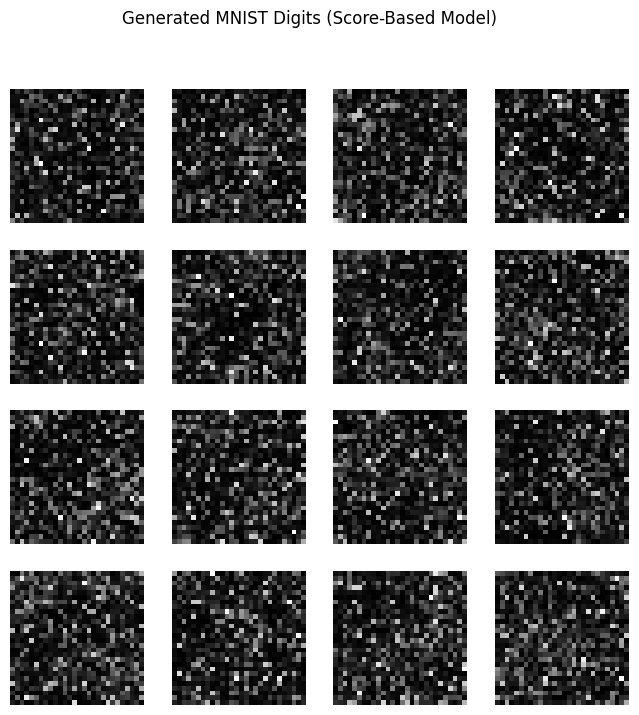

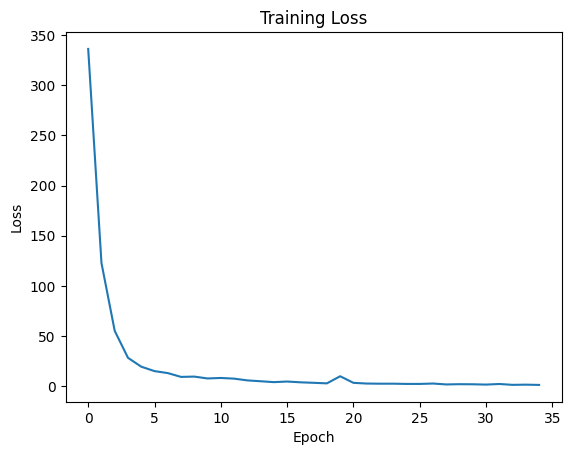

In [95]:
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    img=sams[i,0]
    img=(img-img.min())/(img.max()-img.min())
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.suptitle("Generated MNIST Digits (Score-Based Model)")
plt.show()

plt.figure()
plt.plot(hloss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()